In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Parametrii Digital Twin

In [3]:
GRID_SIZE = 150
D_O2 = 0.1 # coeficient de difuzie scalat pentru grid
LAMBDA_O2 = 0.044
O2_BOUNDARY = 220.0
O2_HYPOXIA = 10.0
O2_NECROSIS = 1.0
PROB_DIV_BASE = 0.04
DIFUSION_STEP = 1000


# Initialization Lattice

In [ ]:
# Initialization Lattice
grid_celule = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
grid_oxigen = np.full((GRID_SIZE, GRID_SIZE), O2_BOUNDARY, dtype=float)

mid = GRID_SIZE // 2

# Setăm raza inițială a agregatului celular (în număr de "pixeli/celule")
# O rază de 13 va genera un diametru inițial de aproximativ 350 - 400 µm
raza_initiala = 13 

for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        # Dacă distanța de la centru până la punctul (i,j) este mai mică decât raza, pune o celulă vie
        if (i - mid)**2 + (j - mid)**2 <= raza_initiala**2:
            grid_celule[i, j] = 1

# O2_DEF

In [5]:
def difuzie_oxigen(oxigen_vechi, celule):
    oxigen_nou = np.copy(oxigen_vechi)
    
    # Decupam matricea pentru a obtine vecinii tuturor celulelor SIMULTAN
    O_sus    = oxigen_vechi[:-2, 1:-1]
    O_jos    = oxigen_vechi[2:,  1:-1]
    O_stanga = oxigen_vechi[1:-1, :-2]
    O_dreapta= oxigen_vechi[1:-1, 2:]
    O_centru = oxigen_vechi[1:-1, 1:-1]
    
    # Laplacian discret calculat pentru toata grila in milisecunde
    laplacian = O_sus + O_jos + O_stanga + O_dreapta - 4 * O_centru
    
    # Consumul aplicat doar unde celulele au valoarea 1
    consum = np.where(celule[1:-1, 1:-1] == 1, LAMBDA_O2, 0.0)
    
    # Actualizam partea interioara a grilei dintr-un foc
    oxigen_nou[1:-1, 1:-1] = O_centru + (D_O2 * laplacian) - consum
    
    return np.clip(oxigen_nou, 0.0, O2_BOUNDARY)

# Biology Update

In [6]:
def update_biologie(celule, oxigen):
    celule_noi = np.copy(celule)
    
    for i in range(1, GRID_SIZE - 1):
        for j in range(1, GRID_SIZE - 1):
            if celule[i, j] == 1: # Celulă vie
                nivel_O2 = oxigen[i, j]
                
                # Regula 1: Necroza (fără oxigen)
                if nivel_O2 <= O2_NECROSIS:
                    celule_noi[i, j] = 2 
                    continue
                
                # Regula 2: Hipoxia (quiescentă)
                if nivel_O2 <= O2_HYPOXIA:
                    continue 
                
                # Probabilitatea ta curată de 0.04 (astfel sferoidul se va face mare!)
                if np.random.rand() < PROB_DIV_BASE:
                    vecini_liberi = []
                    # Căutăm spațiu
                    if celule[i+1, j] == 0: vecini_liberi.append((i+1, j))
                    if celule[i-1, j] == 0: vecini_liberi.append((i-1, j))
                    if celule[i, j+1] == 0: vecini_liberi.append((i, j+1))
                    if celule[i, j-1] == 0: vecini_liberi.append((i, j-1))
                    
                    if vecini_liberi:
                        nou_i, nou_j = vecini_liberi[np.random.randint(len(vecini_liberi))]
                        celule_noi[nou_i, nou_j] = 1
                        
    return celule_noi

# Main Loop

In [7]:
zile_de_simulat = 45
ore_totale = zile_de_simulat * 24

# Liste pentru grafic
istoric_volum = []
axa_timp = []

print("Simularea a inceput. Calculez...")
for ora in range(ore_totale):
    
    # Difuzia
    for _ in range(DIFUSION_STEP):
        grid_oxigen = difuzie_oxigen(grid_oxigen, grid_celule)
        
    grid_celule = update_biologie(grid_celule, grid_oxigen)
    
    # Salvăm datele o dată la 24 de ore
    if ora % 24 == 0:
        ziua_curenta = ora // 24
        volum_curent = np.sum(grid_celule > 0) # Celule Vii + Necrotice
        
        istoric_volum.append(volum_curent)
        axa_timp.append(ziua_curenta)
        print(f"Ziua {ziua_curenta} finalizata | Volum: {volum_curent} celule")

# Salvăm ultima valoare
istoric_volum.append(np.sum(grid_celule > 0))
axa_timp.append(zile_de_simulat)

Simularea a inceput. Calculez...
Ziua 0 finalizata | Volum: 9 celule
Ziua 1 finalizata | Volum: 17 celule
Ziua 2 finalizata | Volum: 35 celule
Ziua 3 finalizata | Volum: 58 celule
Ziua 4 finalizata | Volum: 84 celule
Ziua 5 finalizata | Volum: 110 celule
Ziua 6 finalizata | Volum: 149 celule
Ziua 7 finalizata | Volum: 202 celule
Ziua 8 finalizata | Volum: 251 celule
Ziua 9 finalizata | Volum: 304 celule
Ziua 10 finalizata | Volum: 361 celule
Ziua 11 finalizata | Volum: 454 celule
Ziua 12 finalizata | Volum: 532 celule
Ziua 13 finalizata | Volum: 620 celule
Ziua 14 finalizata | Volum: 715 celule
Ziua 15 finalizata | Volum: 817 celule
Ziua 16 finalizata | Volum: 937 celule
Ziua 17 finalizata | Volum: 1049 celule
Ziua 18 finalizata | Volum: 1167 celule
Ziua 19 finalizata | Volum: 1277 celule
Ziua 20 finalizata | Volum: 1418 celule
Ziua 21 finalizata | Volum: 1579 celule
Ziua 22 finalizata | Volum: 1722 celule
Ziua 23 finalizata | Volum: 1894 celule
Ziua 24 finalizata | Volum: 2059 celule


# Plotting

<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\david\AppData\Local\Temp\ipykernel_30120\2035262318.py:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax[1].set_title("Harta Oxigenului ($\mu$M)")


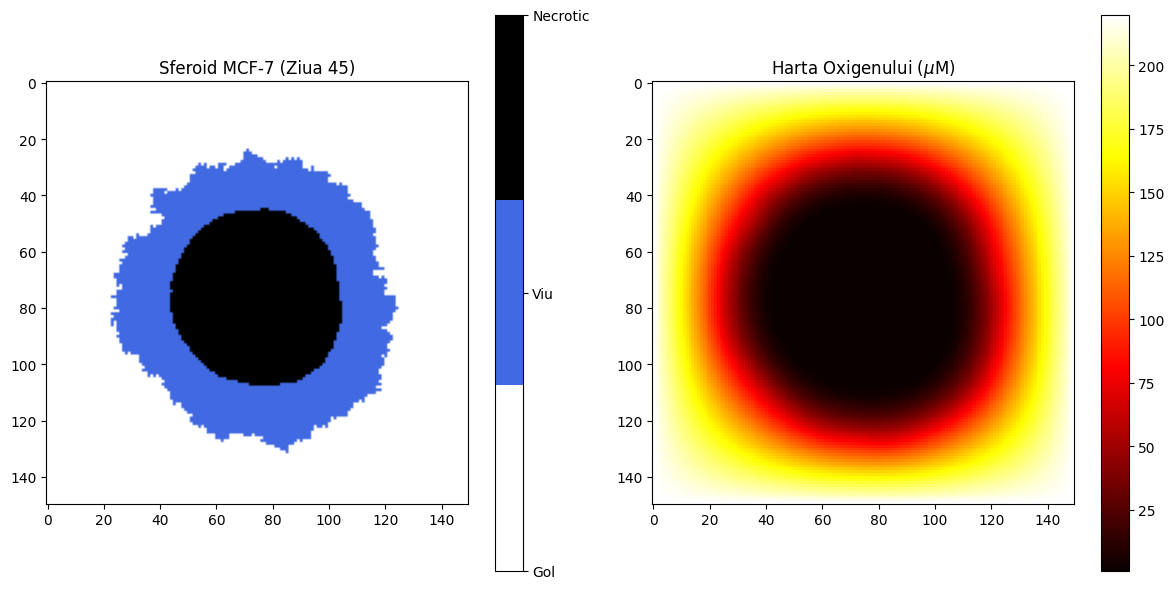

In [8]:
cmap_celule = mcolors.ListedColormap(['white', 'royalblue', 'black'])
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

im1 = ax[0].imshow(grid_celule, cmap=cmap_celule, vmin=0, vmax=2)
ax[0].set_title(f"Sferoid MCF-7 (Ziua {zile_de_simulat})")
fig.colorbar(im1, ax=ax[0], ticks=[0, 1, 2], format=plt.FuncFormatter(lambda val, loc: ['Gol', 'Viu', 'Necrotic'][val]))

im2 = ax[1].imshow(grid_oxigen, cmap='hot', interpolation='nearest')
ax[1].set_title("Harta Oxigenului ($\mu$M)")
fig.colorbar(im2, ax=ax[1])

plt.tight_layout()
plt.show()

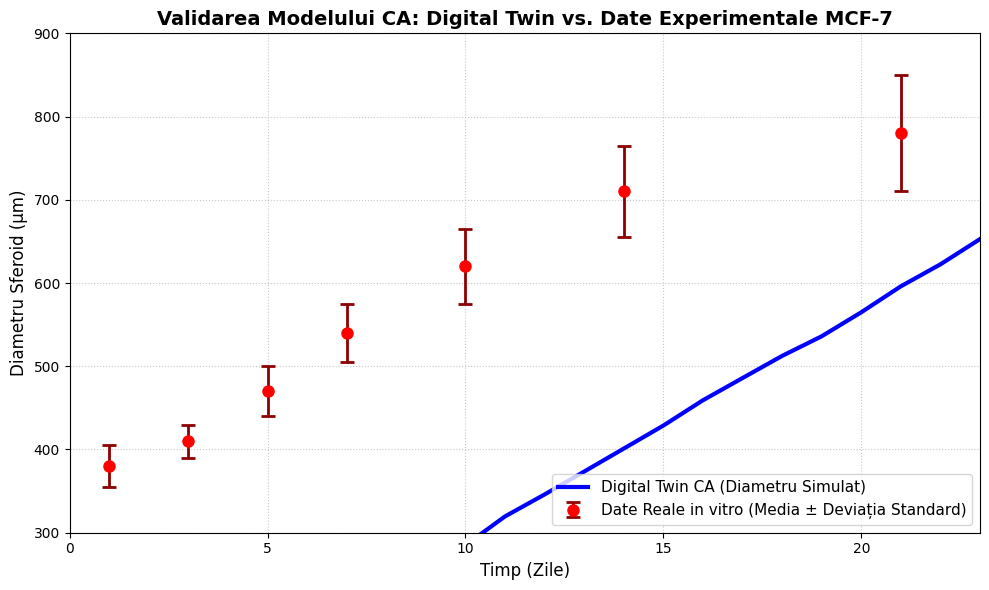

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Datele experimentale reale (in vitro) pentru MCF-7
# Acestea sunt mediile și deviațiile standard extrase din literatură
zile_exp = [1, 3, 5, 7, 10, 14, 21]
diametre_exp = [380, 410, 470, 540, 620, 710, 780]
erori_exp = [25, 20, 30, 35, 45, 55, 70]

# 2. Conversia datelor din simularea ta (Digital Twin)
# Transformăm lista ta 'istoric_volum' (număr celule) într-un array NumPy
istoric_volum_np = np.array(istoric_volum)

# Calculăm diametrul fizic echivalent (în micrometri)
diametre_simulate = 15 * np.sqrt(istoric_volum_np)

# 3. Desenarea graficului de validare
plt.figure(figsize=(10, 6))

# Plotează datele experimentale cu bare de eroare (yerr)
plt.errorbar(zile_exp, diametre_exp, yerr=erori_exp, fmt='o', color='red', 
             ecolor='darkred', elinewidth=2, capsize=5, capthick=2, markersize=8, 
             label='Date Reale in vitro (Media ± Deviația Standard)')

# Plotează rezultatul simulării tale CA
plt.plot(axa_timp, diametre_simulate, color='blue', linewidth=3, 
         label='Digital Twin CA (Diametru Simulat)')

# Detalii estetice și etichete
plt.title('Validarea Modelului CA: Digital Twin vs. Date Experimentale MCF-7', fontsize=14, fontweight='bold')
plt.xlabel('Timp (Zile)', fontsize=12)
plt.ylabel('Diametru Sferoid (µm)', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)

# Limităm axele pentru a ne concentra exact pe fereastra experimentului in vitro
plt.xlim(0, 23)
plt.ylim(300, 900)

plt.tight_layout()
plt.show()